In [1]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')


import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder

sw = set(stopwords.words('english'))
lm = WordNetLemmatizer()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ANKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [2]:
df=pd.read_csv('Dataset/bbc_data.csv')
df.drop_duplicates()

,data,labels
0,Musicians to tackle US red tape Musicians gro...,entertainment
1,"U2s desire to be number one U2, who have won ...",entertainment
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment
3,Snicket tops US box office chart The film ada...,entertainment
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment
...,...,...
2220,Warning over Windows Word files Writing a Mic...,tech
2221,Fast lifts rise into record books Two high-sp...,tech
2222,Nintendo adds media playing to DS Nintendo is...,tech
2223,Fast moving phone viruses appear Security fir...,tech


## Data preprocessing

In [3]:
def preprocess_text_df(df, text_col='data', label_col='labels'):


    def clean(t):
        t = str(t).lower()
        t = re.sub(r'[^a-z0-9\s]', ' ', t)
        tokens = word_tokenize(t)
        tokens = [lm.lemmatize(w) for w in tokens if w not in sw]
        return " ".join(tokens)

    df['clean_text'] = df[text_col].apply(clean)
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df[label_col])

    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(label_mapping)

    return df, le


df_processed, label_encoder = preprocess_text_df(df, text_col='data', label_col='labels')


{'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


## Glove embedding


In [4]:
def load_glove_100(glove_path):
    embeddings = {}
    with open(glove_path, encoding="utf8") as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vec = np.asarray(parts[1:], dtype="float32")
            embeddings[word] = vec
    return embeddings

def text_to_glove_vector(text, embeddings, dim=100):
    if not isinstance(text, str):
        return np.zeros(dim).tolist()
    words = text.split()
    vectors = [embeddings[w] for w in words if w in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim).tolist()
    return np.mean(vectors, axis=0).tolist()

def df_to_glove_embeddings(df, text_col, embeddings, dim=100):
    df[text_col] = df[text_col].fillna("")
    df['glove_vec'] = df[text_col].apply(lambda x: text_to_glove_vector(x, embeddings, dim))
    return df

embeddings = load_glove_100("glove.6B.100d.txt")
df = df_to_glove_embeddings(df, "clean_text", embeddings)


In [5]:
X = np.vstack(df['glove_vec'].values)
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## EDA (Exploratory Data Analysis)

Generating NLP EDA Visualizations...


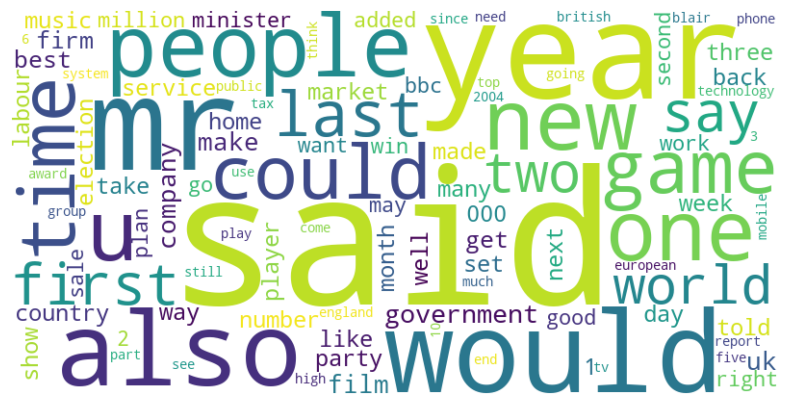

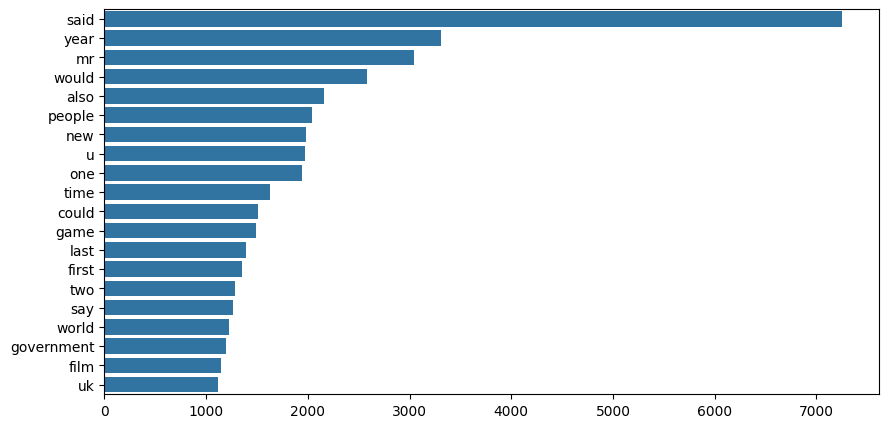

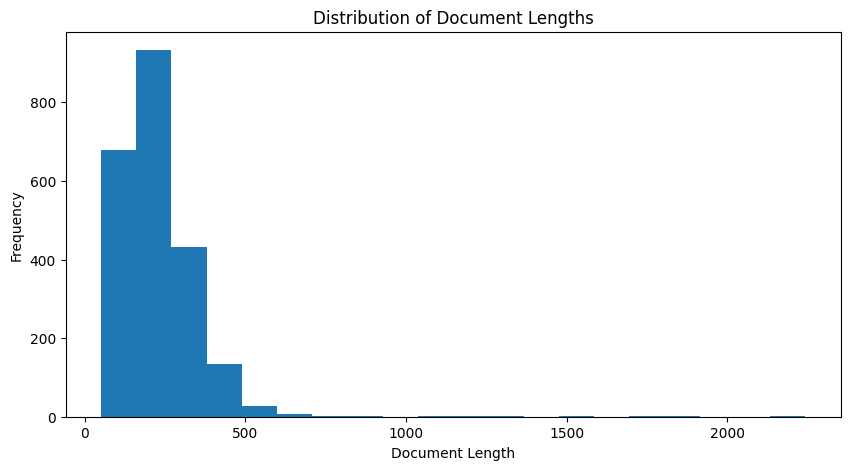

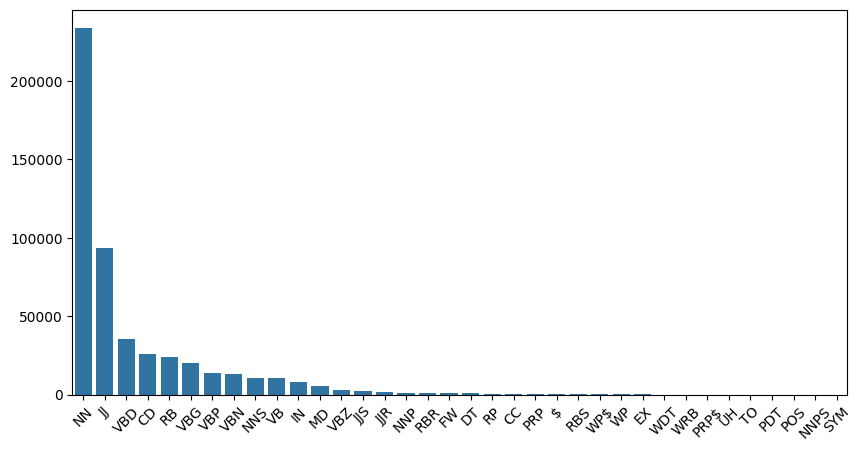

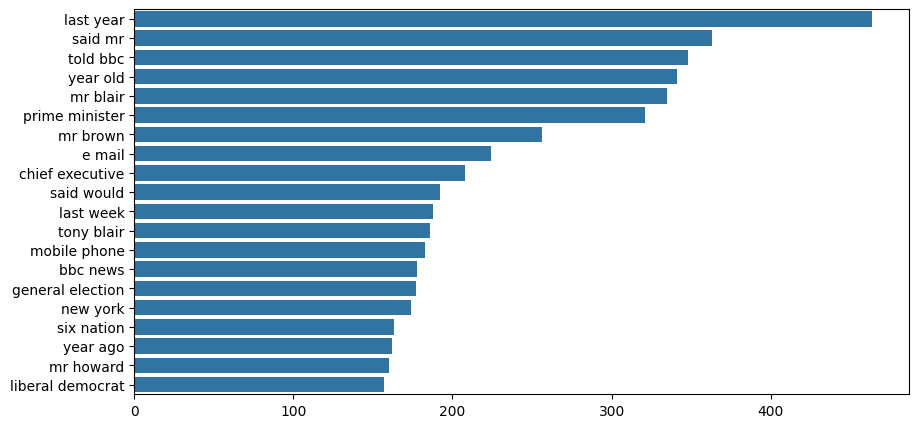

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.util import ngrams

def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    print("Generating NLP EDA Visualizations...")

    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    word_freq = Counter(all_tokens)
    wc = WordCloud(
        width=800,
        height=400,
        max_words=num_words,
        background_color='white'
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words))
    plt.show()

    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]

    plt.figure(figsize=(10, 5))
    plt.hist(doc_lengths, bins=20)
    plt.xlabel("Document Length")
    plt.ylabel("Frequency")
    plt.title("Distribution of Document Lengths")
    plt.show()

    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs))
    plt.xticks(rotation=45)
    plt.show()

    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels)
    plt.show()


X_text = df["clean_text"].astype(str).tolist()
eda_nlp_analysis(X_text, num_words=100, top_n_words=20)


In [7]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

os.makedirs("results", exist_ok=True)

label_map = {
    0: "business",
    1: "entertainment",
    2: "politics",
    3: "sport",
    4: "tech"
}

c = list(label_map.values())

num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))


def plot_and_save_auc_roc(model, X_test, y_test, model_name):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = label_binarize(
            model.predict(X_test),
            classes=list(range(num_classes))
        )

    plt.figure()

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{c[i]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"AUC-ROC Curve - {model_name}")
    plt.legend()

    path = f"results/{model_name}_auc_roc.png"
    plt.savefig(path, dpi=300)
    plt.show()
    plt.close()

    print("Saved:", path)


def plot_and_save_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.colorbar()

    plt.xticks(range(len(c)), c)
    plt.yticks(range(len(c)), c)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.savefig(f"results/{model_name}_confusion_matrix.png", dpi=300)
    plt.show()
    plt.close()


## Model Training and Building

TRAIN ACCURACY: 22.98 %
TEST ACCURACY : 22.92 %
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       102
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        84
           3       0.23      1.00      0.37       102
           4       0.00      0.00      0.00        80

    accuracy                           0.23       445
   macro avg       0.05      0.20      0.07       445
weighted avg       0.05      0.23      0.09       445



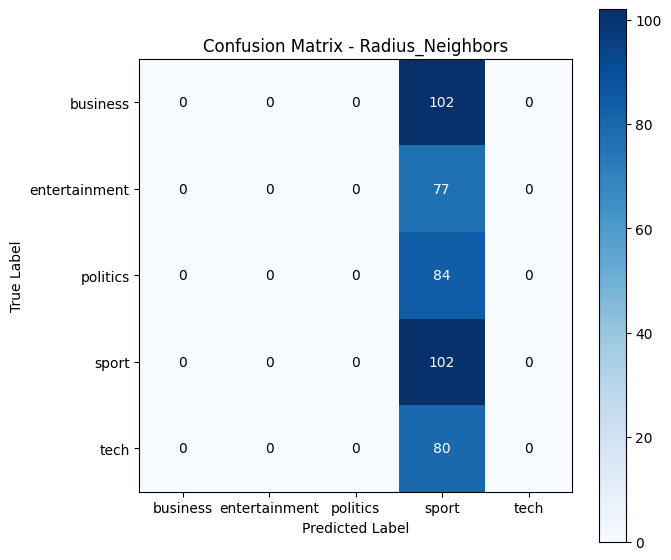

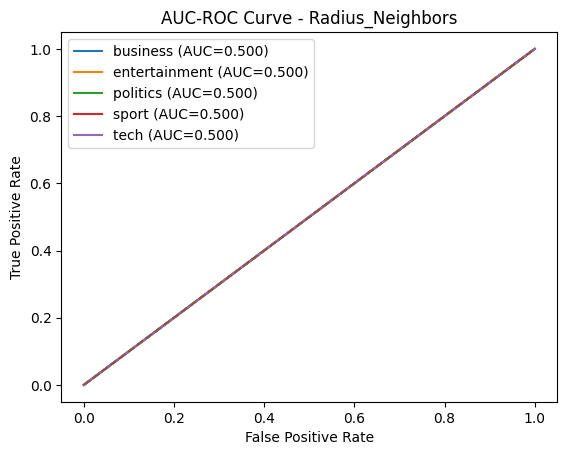

Saved: results/Radius_Neighbors_auc_roc.png


In [40]:
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os
import numpy as np

os.makedirs("model", exist_ok=True)

rnc_model = RadiusNeighborsClassifier(
    radius=5.0,
    weights="uniform",
    metric="euclidean",
    outlier_label=0
)

rnc_model.fit(X_train, y_train)

joblib.dump(rnc_model, "model/radius_neighbors.pkl")

y_train_pred = rnc_model.predict(X_train)
y_test_pred = rnc_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("TRAIN ACCURACY:", round(train_acc * 100, 2), "%")
print("TEST ACCURACY :", round(test_acc * 100, 2), "%")
print(classification_report(y_test, y_test_pred, zero_division=0))

plot_and_save_confusion_matrix(y_test, y_test_pred, "Radius_Neighbors")

plot_and_save_auc_roc(rnc_model, X_test, y_test, "Radius_Neighbors")


TRAIN ACCURACY: 100.0 %
TEST ACCURACY : 87.64 %
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       102
           1       0.87      0.94      0.90        77
           2       0.90      0.87      0.88        84
           3       0.91      0.91      0.91       102
           4       0.84      0.85      0.84        80

    accuracy                           0.88       445
   macro avg       0.88      0.88      0.88       445
weighted avg       0.88      0.88      0.88       445



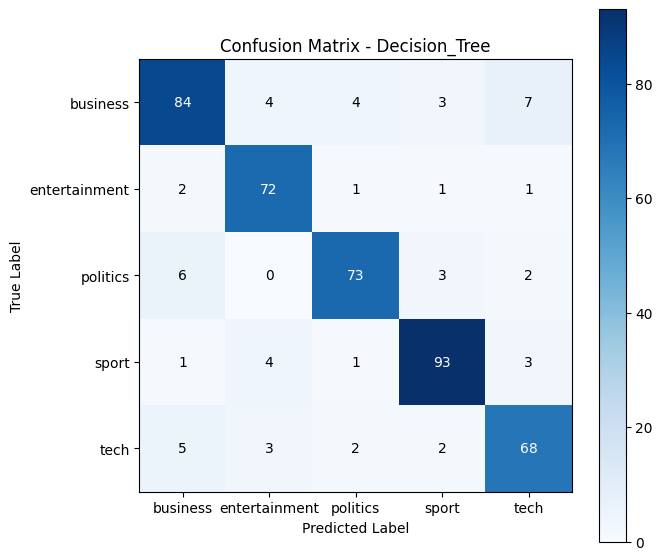

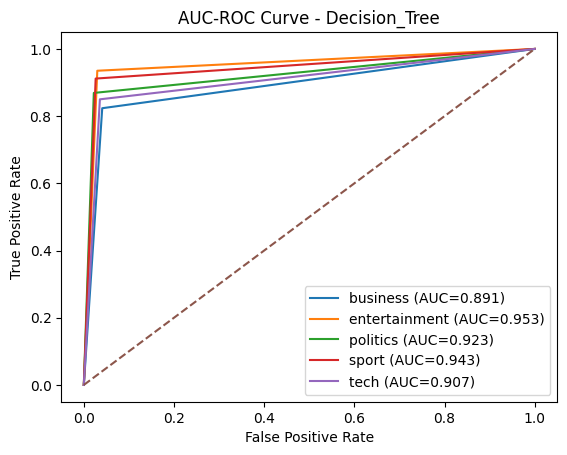

Saved: results/Decision_Tree_auc_roc.png


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os
import numpy as np

os.makedirs("model", exist_ok=True)

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

dt_model.fit(X_train, y_train)

joblib.dump(dt_model, "model/decision_tree.pkl")

y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("TRAIN ACCURACY:", round(train_acc * 100, 2), "%")
print("TEST ACCURACY :", round(test_acc * 100, 2), "%")
print(classification_report(y_test, y_test_pred, zero_division=0))

dt_model = joblib.load("model/decision_tree.pkl")

y_pred_dt = dt_model.predict(X_test)

plot_and_save_confusion_matrix(y_test, y_pred_dt, "Decision_Tree")

plot_and_save_auc_roc(dt_model, X_test, y_test, "Decision_Tree")


TRAIN ACCURACY: 94.66 %
TEST ACCURACY : 93.71 %
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       102
           1       0.99      0.95      0.97        77
           2       0.87      0.94      0.90        84
           3       1.00      0.98      0.99       102
           4       0.95      0.91      0.93        80

    accuracy                           0.94       445
   macro avg       0.94      0.94      0.94       445
weighted avg       0.94      0.94      0.94       445



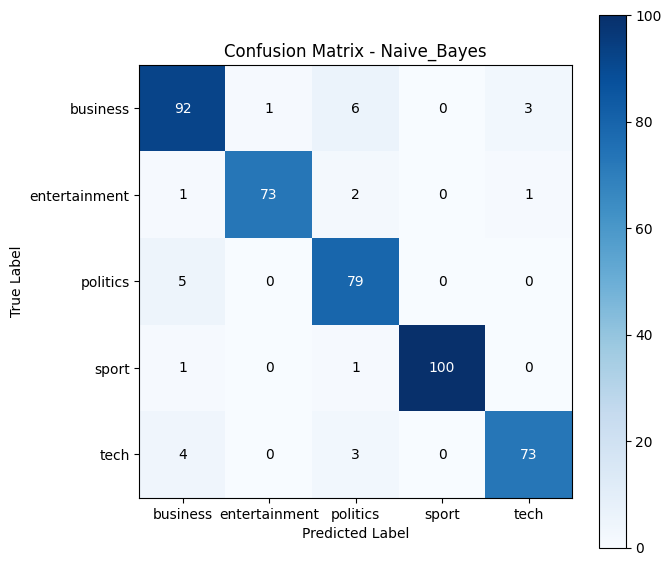

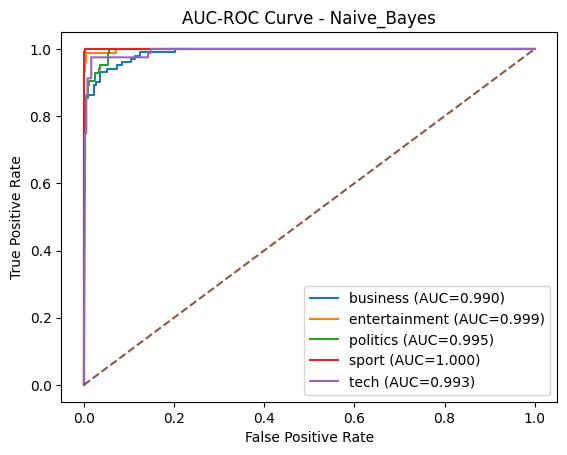

Saved: results/Naive_Bayes_auc_roc.png


In [36]:

os.makedirs("model", exist_ok=True)
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)
joblib.dump(naive_bayes_model, "model/naive_bayes.pkl")
y_train_pred = naive_bayes_model.predict(X_train)
y_test_pred = naive_bayes_model.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("TRAIN ACCURACY:", round(train_acc * 100, 2), "%")
print("TEST ACCURACY :", round(test_acc * 100, 2), "%")
print(classification_report(y_test, y_test_pred, zero_division=0))
y_pred_nb = naive_bayes_model.predict(X_test)

nb_model = joblib.load("model/naive_bayes.pkl")
y_pred_nb = nb_model.predict(X_test)

plot_and_save_confusion_matrix(y_test, y_pred_nb, "Naive_Bayes")
plot_and_save_auc_roc(nb_model, X_test, y_test, "Naive_Bayes")





TRAIN ACCURACY: 100.0 %
TEST ACCURACY : 96.63 %
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       102
           1       1.00      0.99      0.99        77
           2       0.90      1.00      0.95        84
           3       1.00      0.99      1.00       102
           4       0.94      0.97      0.96        80

    accuracy                           0.97       445
   macro avg       0.97      0.97      0.97       445
weighted avg       0.97      0.97      0.97       445



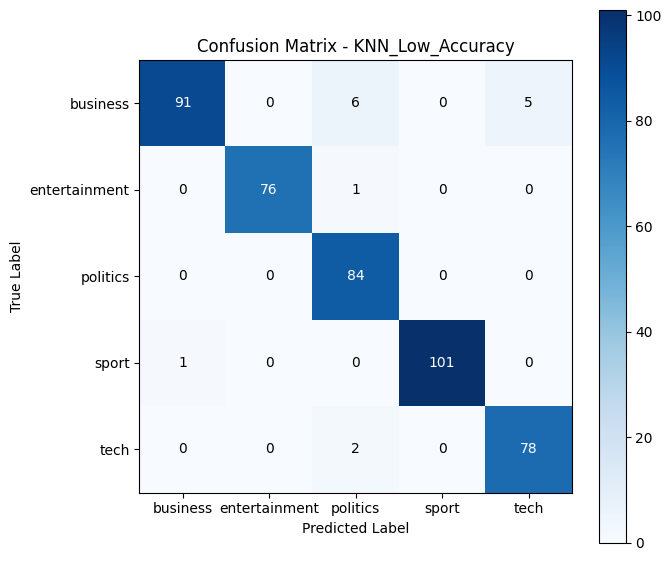

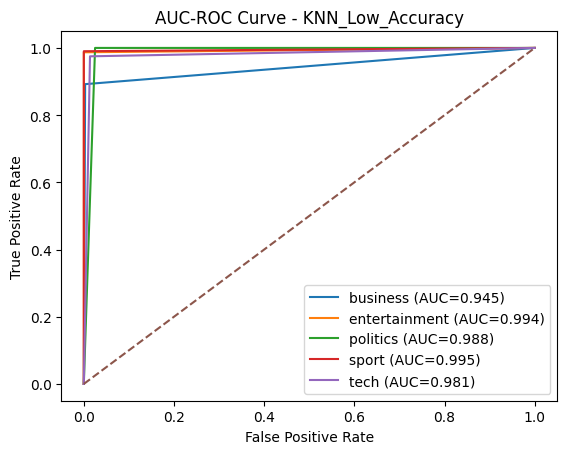

Saved: results/KNN_Low_Accuracy_auc_roc.png


In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

os.makedirs("model", exist_ok=True)

knn_model = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean",
    weights="uniform"
)

knn_model.fit(X_train, y_train)

joblib.dump(knn_model, "model/knn_classifier.pkl")

y_train_pred = knn_model.predict(X_train)
y_test_pred = knn_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("TRAIN ACCURACY:", round(train_acc * 100, 2), "%")
print("TEST ACCURACY :", round(test_acc * 100, 2), "%")
print(classification_report(y_test, y_test_pred, zero_division=0))

plot_and_save_confusion_matrix(y_test, y_test_pred, "KNN_Low_Accuracy")
plot_and_save_auc_roc(knn_model, X_test, y_test, "KNN_Low_Accuracy")


In [39]:
models = {
    "radius neighbors": joblib.load("model/radius_neighbors.pkl"),


    "decision_tree": joblib.load("model/decision_tree.pkl"),"Naive Bayes": joblib.load("model/naive_bayes.pkl"),
     "KNN": joblib.load("model/knn_classifier.pkl"),
}

results = []

for name, model in models.items():
    if name == "Kernel Ridge":
        y_pred = np.rint(model.predict(X_test)).astype(int)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append([name, round(acc * 100, 2)])

accuracy_table = pd.DataFrame(
    results,
    columns=["Algorithm", "Accuracy (%)"]
)

print("\n========  COMPARISON TABLE =======\n")


accuracy_table



========  COMPARISON TABLE =======



,Algorithm,Accuracy (%)
0,radius neighbors,22.92
1,decision_tree,87.64
2,Naive Bayes,93.71
3,KNN,96.63


# Testing with Prediction Single prediction and Batchwise Predictions

### Preprocessing for Test

In [16]:
model = joblib.load("model/knn_classifier.pkl")

label_map = {
    0: "business",
    1: "entertainment",
    2: "politics",
    3: "sport",
    4: "tech"
}

def load_glove_100(glove_path):
    embeddings = {}
    with open(glove_path, encoding="utf8") as f:
        for line in f:
            parts = line.split()
            embeddings[parts[0]] = np.asarray(parts[1:], dtype="float32")
    return embeddings

embeddings = load_glove_100("glove.6B.100d.txt")

sw = set(stopwords.words('english'))
lm = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lm.lemmatize(w) for w in tokens if w not in sw]
    return " ".join(tokens)

def text_to_vector(text, dim=100):
    words = text.split()
    vecs = [embeddings[w] for w in words if w in embeddings]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

def predict_from_text(text):
    cleaned = preprocess_text(text)
    vec = text_to_vector(cleaned)
    vec = np.array(vec).reshape(1, -1)
    pred = model.predict(vec)[0]
    return label_map[int(pred)]


In [17]:
def predict_batch_from_csv(csv_path, text_column="data"):
    df = pd.read_csv(csv_path)
    df[text_column] = df[text_column].fillna("")

    print("\n===== ALL BATCH PREDICTIONS =====\n")

    for text in df[text_column]:
        category = predict_from_text(text)
        print(text)
        print("➜ Predicted Category:", category)
        print("-" * 100)

### Single Prediction

In [18]:
sample_text = """Rocker Doherty in on-stage fight  Rock singer Pete Doherty has been involved in a fight with his bands guitarist at their biggest gig to date.  Babyshambles played for 5,000 fans at Londons Brixton Academy on Tuesday. The former Libertines singer traded blows with guitarist Patrick Walden. They were separated and bundled off stage before returning to end the set. The show was earlier held up due to audience overcrowding. On Monday Doherty faced blackmail and robbery charges in court, which he denies. He is out on xc2xa350,000 bail and the judge agreed to extend his 2200 GMT curfew deadline by two hours so he could play the Brixton gig.  Babyshambles, which he formed after his acrimonious departure from the Libertines, played a warm-up show at The Garage, north London, on Monday. On Tuesday, Doherty and his three bandmates were introduced to the crowd by Mick Jones, the former Clash guitarist who produced the Libertines second album. Babyshambles took the stage to a frenzied reception at 2200 GMT, launching into their last single, Killamangiro, which reached number eight in December. But the group had to stop during the next song to persuade fans not to push forward and allow security guards to pull people out of the crush. Doherty appealed to fans to calm down, saying: "Theres a few people getting hurt down the front, youve got to move back."  The music resumed minutes later but after several more songs, the singer appeared to accidentally disconnect Waldens guitar, leading the pair to trade kicks and punches. Bouncers stepped in and the band left the stage, but returned after five minutes and finished their 50-minute performance with no further trouble. Doherty, 25, had to be home by midnight to observe the curfew, which is one of the conditions of his bail. On Monday, the judge agreed to allow him to perform on condition that requests for changes to his bail terms were "not too regular an occurrence". The singer was arrested with fellow musician Alan Wass on 2 February after an alleged dispute with documentary-maker Max Carlish at a London hotel. They are next due in court on 18 April.
"""
print("Predicted Category:", predict_from_text(sample_text))


Predicted Category: entertainment


### Batwise Prediction





In [19]:
predict_batch_from_csv("Dataset/test.csv", text_column="data")



===== ALL BATCH PREDICTIONS =====

Musicians to tackle US red tape  Musicians groups are to tackle US visa regulations which are blamed for hindering British acts chances of succeeding across the Atlantic.  A singer hoping to perform in the US can expect to pay $1,300 (xc2xa3680) simply for obtaining a visa. Groups including the Musicians Union are calling for an end to the "raw deal" faced by British performers. US acts are not faced with comparable expense and bureaucracy when visiting the UK for promotional purposes.  Nigel McCune from the Musicians Union said British musicians are "disadvantaged" compared to their US counterparts. A sponsor has to make a petition on their behalf, which is a form amounting to nearly 30 pages, while musicians face tougher regulations than athletes and journalists. "If you make a mistake on your form, you risk a five-year ban and thus the ability to further your career," says Mr McCune.  "The US is the worlds biggest music market, which means somethi